In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 设置绘图风格
sns.set_theme(style="whitegrid")

# 导入插值后的数据
try:
    df = pd.read_csv("data/cex4WindDataInterpolated.csv")
    print("数据加载成功！")
except FileNotFoundError:
    print("找不到文件 cex4WindDataInterpolated.csv，请检查文件路径。")
    exit()

# 转换为日期时间格式
# 变量 't' 是时间戳 (UTC) [cite: 1]
df['t'] = pd.to_datetime(df['t'], format="%Y-%m-%d %H:%M:%S", utc=True)

# 设置 't' 为索引
df.set_index('t', inplace=True)

# 打印数据概览
print("\n数据框前5行:")
print(df.head())
print("\n数据摘要信息:")
df.info()

数据加载成功！

数据框前5行:
                             toy      p  Ws1    Wd1     T1  Ws2    Wd2     T2  \
t                                                                               
1999-01-01 03:00:00+00:00  0.125  1.267  4.9  135.0  275.8  4.9  135.0  275.8   
1999-01-01 04:00:00+00:00  0.167  1.515  5.0  126.9  275.8  5.0  126.9  275.8   
1999-01-01 05:00:00+00:00  0.208  1.915  5.9  135.7  275.5  5.9  135.7  275.5   
1999-01-01 06:00:00+00:00  0.250  1.613  5.3  146.6  275.0  5.3  146.6  275.0   
1999-01-01 07:00:00+00:00  0.292  1.776  6.1  117.4  274.5  5.9  130.2  274.8   

                           Ws3    Wd3     T3  
t                                             
1999-01-01 03:00:00+00:00  4.9  135.0  275.8  
1999-01-01 04:00:00+00:00  5.0  126.9  275.8  
1999-01-01 05:00:00+00:00  5.9  135.7  275.5  
1999-01-01 06:00:00+00:00  5.3  146.6  275.0  
1999-01-01 07:00:00+00:00  5.9  130.2  274.8  

数据摘要信息:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 37941 entries, 1999-01-0

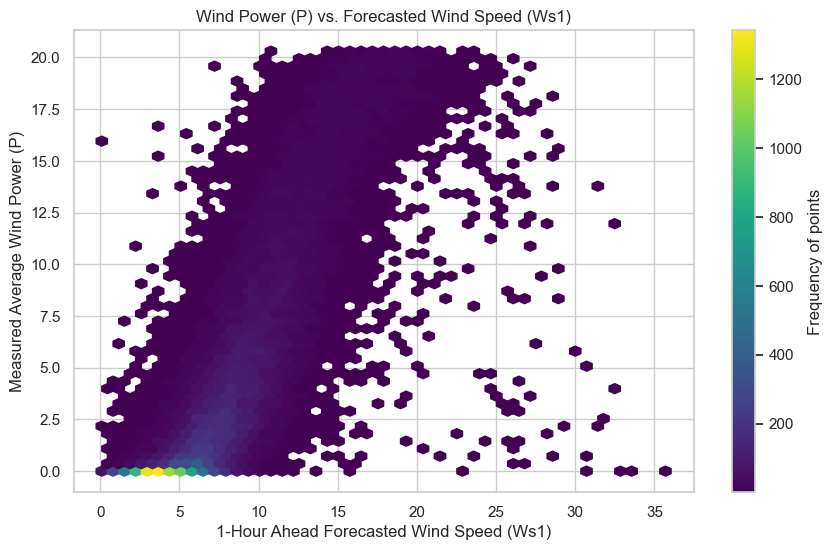

In [3]:
## 📈 功率曲线分析 (P vs. Ws1)

# P 是实测平均风力发电量 [cite: 1]
# Ws1 是 1-小时超前预测风速 [cite: 1]

plt.figure(figsize=(10, 6))
# 使用 hexbin 来显示数据密度，因为数据点非常多
plt.hexbin(df['Ws1'], df['p'], gridsize=50, cmap='viridis', mincnt=1)
cb = plt.colorbar(label='Frequency of points')
plt.xlabel('1-Hour Ahead Forecasted Wind Speed (Ws1)')
plt.ylabel('Measured Average Wind Power (P)')
plt.title('Wind Power (P) vs. Forecasted Wind Speed (Ws1)')
plt.show()
#

/Users/chrix/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chrix/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/chrix/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1057: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_data = data.groupby(
/Users/chrix/miniconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When gro

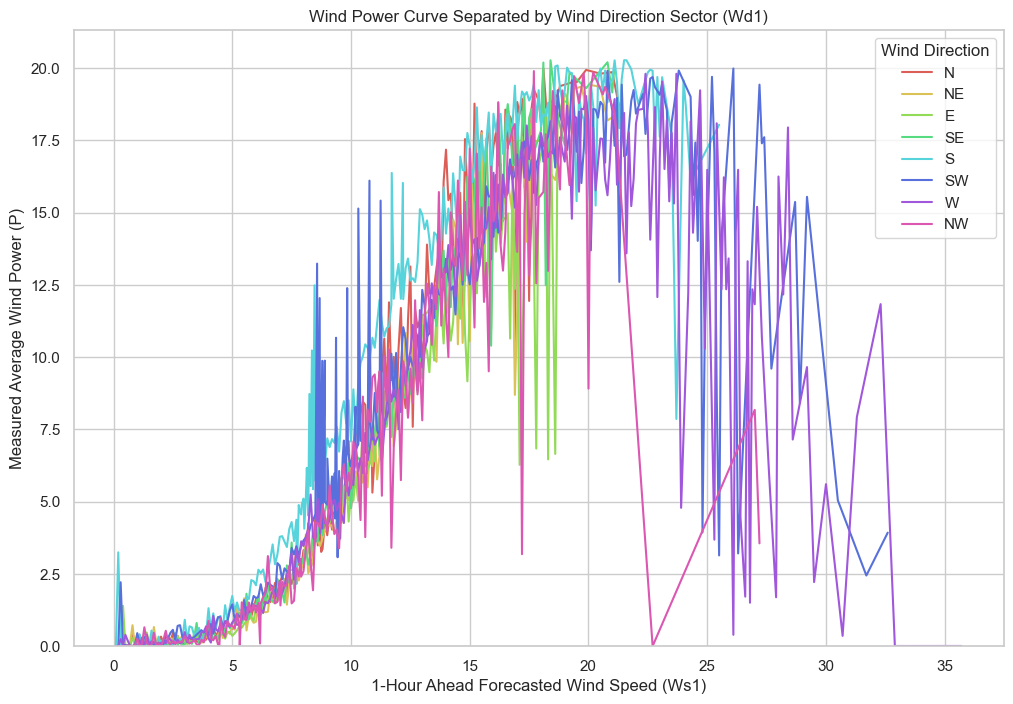

In [5]:
## 🧭 风向对功率曲线的影响 (P vs. Ws1 分组 Wd1)

# 将风向 (Wd1) 转换为 8 个方向的分箱
bins = [0, 45, 90, 135, 180, 225, 270, 315, 360]
labels = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']
df['Wd_Sector'] = pd.cut(df['Wd1'], bins=bins, labels=labels, right=False, ordered=False)

plt.figure(figsize=(12, 8))
# 使用 Seaborn 的 lineplot 绘制每个风向扇区的平均功率曲线
sns.lineplot(data=df, x='Ws1', y='p', hue='Wd_Sector', errorbar=None,
             palette=sns.color_palette("hls", 8)) # errorbar=None 仅显示平均值
plt.xlabel('1-Hour Ahead Forecasted Wind Speed (Ws1)')
plt.ylabel('Measured Average Wind Power (P)')
plt.title('Wind Power Curve Separated by Wind Direction Sector (Wd1)')
plt.legend(title='Wind Direction')
plt.ylim(0, df['p'].max() * 1.05) # 设置 Y 轴上限
plt.show()

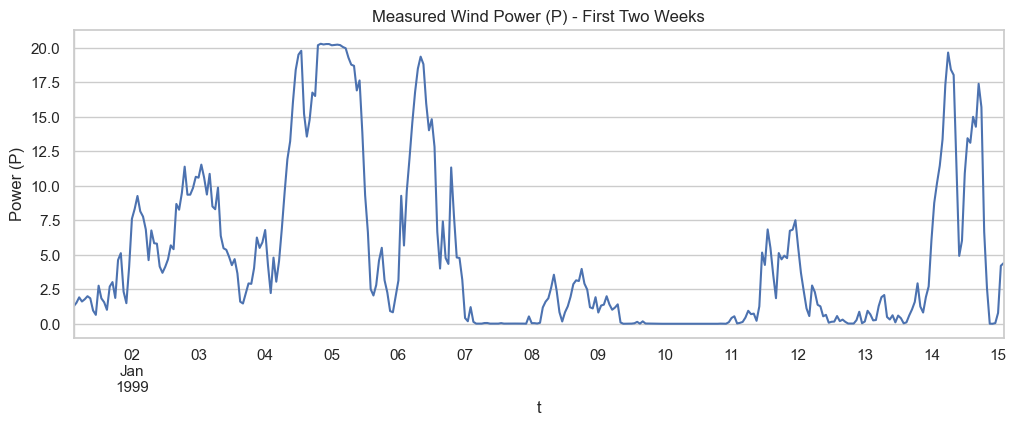

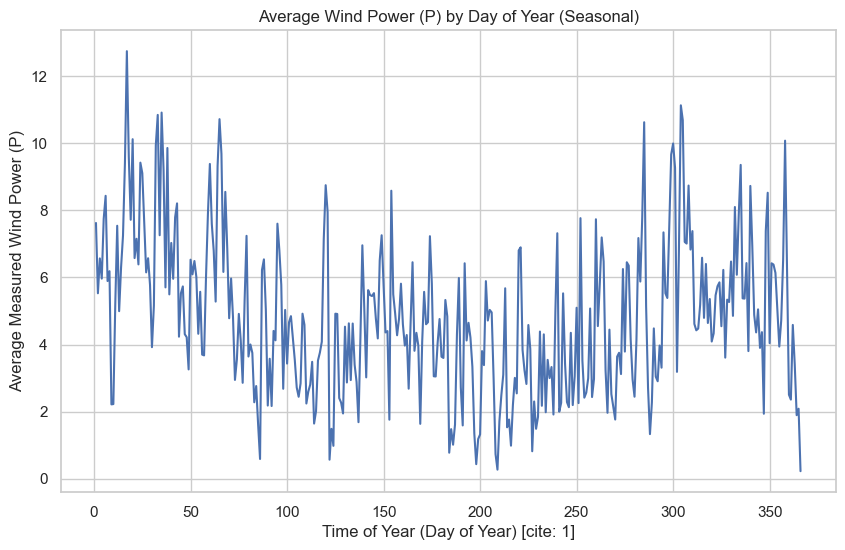

In [8]:
## 🗓️ 时间序列和季节性

# P 的时间序列图 (取一个子集，例如前两周)
plt.figure(figsize=(12, 4))
df['p'].head(24*14).plot()
plt.title('Measured Wind Power (P) - First Two Weeks')
plt.ylabel('Power (P)')
plt.show()

# 功率 P 随年内时间 (toy) 的分布图，观察季节性
plt.figure(figsize=(10, 6))
# 使用 groupby 计算每天的平均功率
df['day_of_year'] = df.index.dayofyear
avg_power_by_day = df.groupby('day_of_year')['p'].mean()
avg_power_by_day.plot()
plt.xlabel('Time of Year (Day of Year) [cite: 1]')
plt.ylabel('Average Measured Wind Power (P)')
plt.title('Average Wind Power (P) by Day of Year (Seasonal)')
plt.show()